# Везилка — дијалектен лексикон како граф на знаење

Овој notebook го прикажува **lean** графот на знаење: зборови (лексеми) мапирани кон
македонските дијалекти, плус меѓудијалектни варијанти.

Содржина:
1. Како изгледа **онтологијата** (визуелизирана, наместо чист OWL код)
2. **Дијалектната хиерархија** (наречје → група → дијалект)
3. **Статистика** на корпусот и распределба на зборови по дијалекти
4. **Венов дијаграм** на споделена лексика меѓу дијалекти
5. **Мрежни прикази** — одделни кластери по дијалект + споделено јадро
6. **Cypher** прашања за живо истражување во Neo4j Aura


In [1]:
# Зависности за notebook-от — се инсталираат во активниот kernel.
# (Нема потреба од посебен requirements фајл; rdflib доаѓа од основниот requirements.txt.)
%pip install -q rdflib matplotlib networkx matplotlib-venn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import json
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib_venn import venn3, venn2
from rdflib import Graph, Namespace
from rdflib.namespace import RDF, RDFS, OWL, SKOS

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['figure.dpi'] = 110

ROOT = Path.cwd()
if not (ROOT / 'ontology').exists():
    ROOT = ROOT.parent

VEZ  = Namespace('http://example.org/vezilka/ontology#')
VEZR = Namespace('http://example.org/vezilka/resource/')

onto = Graph().parse(ROOT / 'ontology' / 'vezilka.ttl', format='turtle')
data = Graph().parse(ROOT / 'output' / 'vezilka-data.ttl', format='turtle')

def lname(u):
    return str(u).split('#')[-1].split('/')[-1]

def pref(node, g=onto, lang='mk'):
    labels = list(g.objects(node, SKOS.prefLabel))
    for o in labels:
        if getattr(o, 'language', None) == lang:
            return str(o)
    return str(labels[0]) if labels else lname(node)

print(f'ontology: {len(onto)} triples   data: {len(data)} triples')

ontology: 300 triples   data: 161977 triples


## 1. Како изгледа онтологијата

Наместо да читаме чист Turtle/OWL, ги цртаме **класите** како јазли и
**object properties** како насочени рабови (`domain → range`). Datatype properties
се прикажани како атрибути под секоја класа.

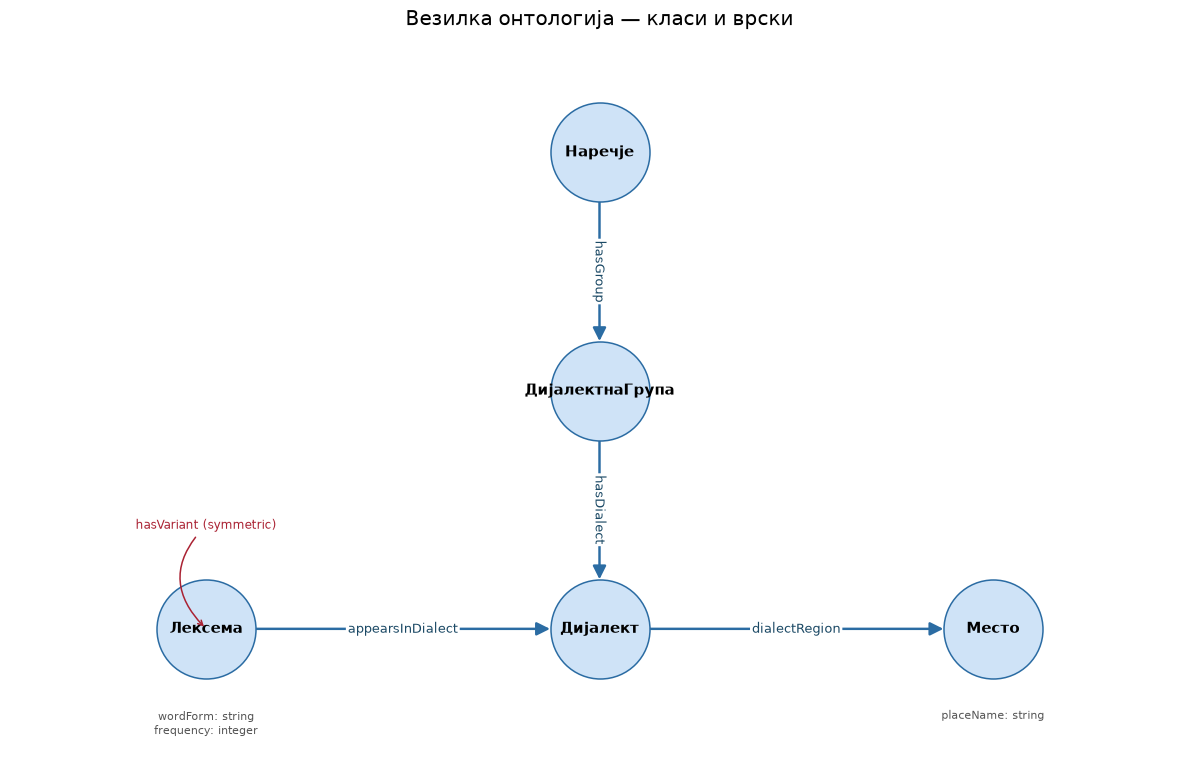

Класи: Дијалект, ДијалектнаГрупа, Лексема, Место, Наречје


In [3]:
classes = sorted(lname(s) for s in onto.subjects(RDF.type, OWL.Class)
                 if str(s).startswith(str(VEZ)))

obj_edges, self_props = [], []
for p in onto.subjects(RDF.type, OWL.ObjectProperty):
    dom, rng = onto.value(p, RDFS.domain), onto.value(p, RDFS.range)
    if dom is None or rng is None:
        continue
    d, r, n = lname(dom), lname(rng), lname(p)
    (self_props if d == r else obj_edges).append((d, r, n))

attrs = {}
for p in onto.subjects(RDF.type, OWL.DatatypeProperty):
    dom, rng = onto.value(p, RDFS.domain), onto.value(p, RDFS.range)
    if dom is None:
        continue
    attrs.setdefault(lname(dom), []).append(f'{lname(p)}: {lname(rng)}')

pos = {
    'Наречје':         (0.0, 3.0),
    'ДијалектнаГрупа': (0.0, 2.0),
    'Дијалект':        (0.0, 1.0),
    'Лексема':         (-2.4, 1.0),
    'Место':           (2.4, 1.0),
}

fig, ax = plt.subplots(figsize=(11, 7))
G = nx.DiGraph()
G.add_nodes_from(classes)
for d, r, n in obj_edges:
    G.add_edge(d, r, label=n)

nx.draw_networkx_nodes(G, pos, node_color='#cfe3f7', edgecolors='#2b6ca3',
                       node_size=4200, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, node_size=4200, arrowsize=18,
                       edge_color='#2b6ca3', width=1.6, ax=ax)
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={(d, r): n for d, r, n in obj_edges},
    font_size=8.5, font_color='#1b4965',
    bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none'), ax=ax)

for cls, items in attrs.items():
    if cls in pos:
        x, y = pos[cls]
        ax.text(x, y - 0.34, '\n'.join(items), ha='center', va='top',
                fontsize=7.5, color='#555')

for d, r, n in self_props:
    if d in pos:
        x, y = pos[d]
        ax.annotate(f'{n} (symmetric)', xy=(x, y), xytext=(x, y + 0.42),
                    ha='center', fontsize=8, color='#a23',
                    arrowprops=dict(arrowstyle='->', color='#a23',
                                    connectionstyle='arc3,rad=0.5'))

ax.set_title('Везилка онтологија — класи и врски', fontsize=13)
ax.margins(0.18); ax.axis('off'); plt.tight_layout(); plt.show()
print('Класи:', ', '.join(classes))

## 2. Дијалектна хиерархија

`Наречје (4) → Дијалектна група (8) → Дијалект (24, од кои 12 со податоци)`.
Зелените дијалекти имаат лексика во корпусот; сивите се дефинирани, но сè уште без податоци.

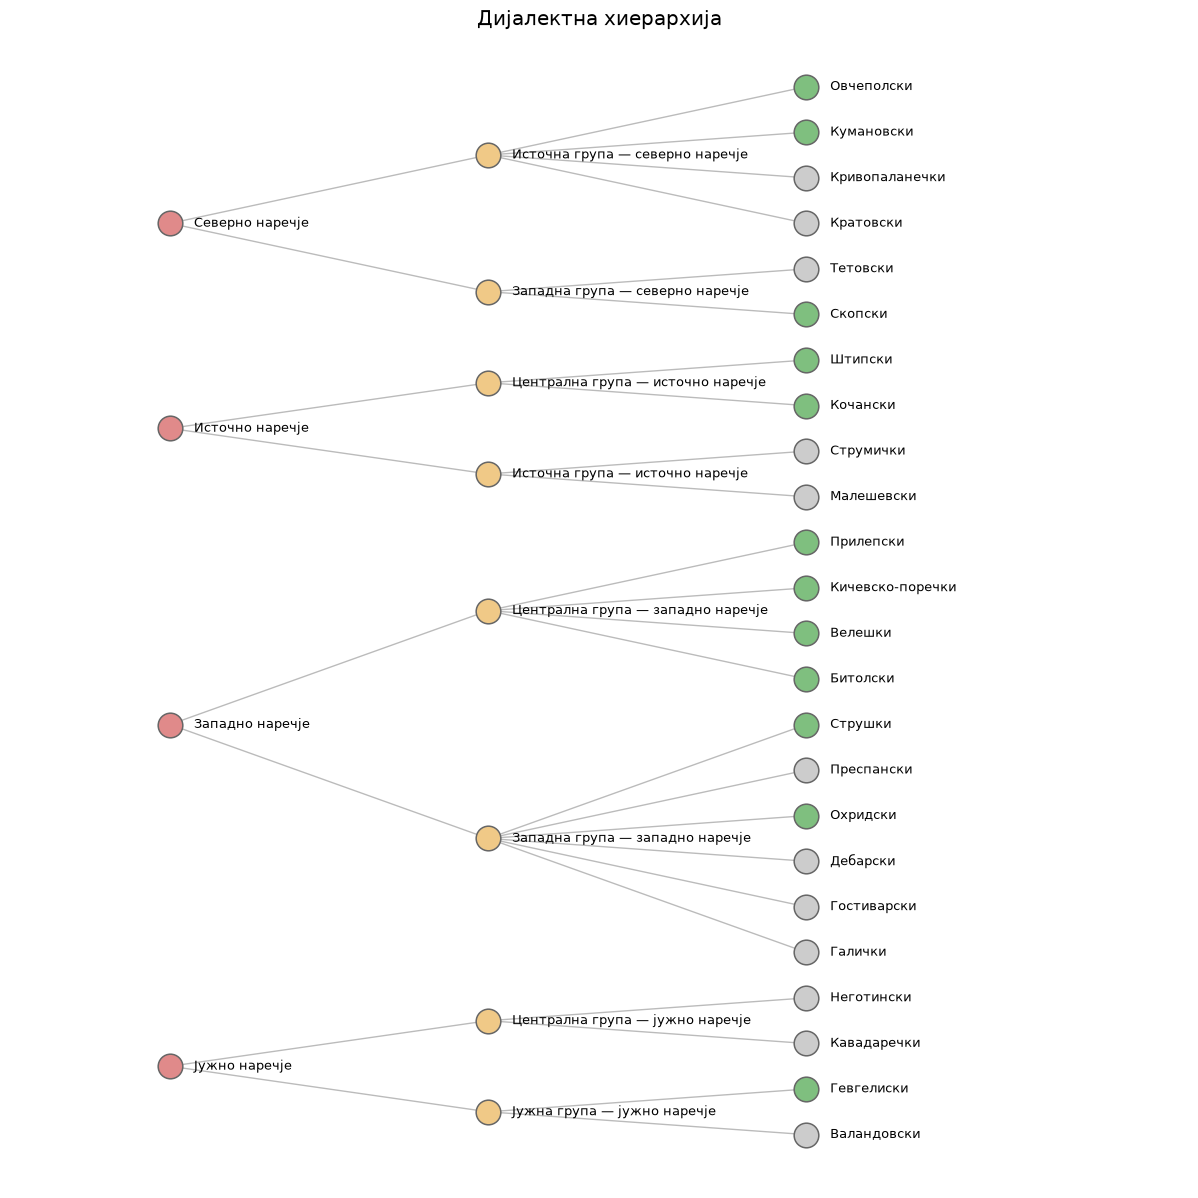

12 дијалекти со податоци: bitolski, gevgeliski, kichevsko_porechki, kochanski, kumanovski, ohridski, ovchepolski, prilepski, shtipski, skopski, strushki, veleshki


In [4]:
with_data = {lname(d) for d in data.objects(None, VEZ.appearsInDialect)}

areas = [s for s in onto.subjects(RDF.type, VEZ['Наречје'])]
rows = []   # (level, node, parent)
y = [0]
posh, color, label = {}, {}, {}

def place_dialect(dnode):
    yy = y[0]; y[0] += 1
    key = ('d', lname(dnode))
    posh[key] = (2, yy); label[key] = pref(dnode)
    color[key] = '#7fbf7f' if lname(dnode) in with_data else '#cccccc'
    return yy

for a in sorted(areas, key=lambda n: pref(n)):
    g_ys = []
    for grp in sorted(onto.objects(a, VEZ.hasGroup), key=lambda n: pref(n)):
        d_ys = [place_dialect(d) for d in
                sorted(onto.objects(grp, VEZ.hasDialect), key=lambda n: pref(n))]
        gy = sum(d_ys) / len(d_ys)
        gkey = ('g', lname(grp)); posh[gkey] = (1, gy)
        label[gkey] = pref(grp); color[gkey] = '#f0c987'; g_ys.append(gy)
        for d in onto.objects(grp, VEZ.hasDialect):
            rows.append((gkey, ('d', lname(d))))
        rows.append((('a', lname(a)), gkey))
    ay = sum(g_ys) / len(g_ys)
    akey = ('a', lname(a)); posh[akey] = (0, ay)
    label[akey] = pref(a); color[akey] = '#e08a8a'

fig, ax = plt.subplots(figsize=(11, 11))
for parent, child in rows:
    x1, y1 = posh[parent]; x2, y2 = posh[child]
    ax.plot([x1, x2], [y1, y2], color='#bbb', lw=0.9, zorder=1)
for key, (x, yy) in posh.items():
    ax.scatter([x], [yy], s=260, c=color[key], edgecolors='#666', zorder=2)
    ax.text(x + 0.05, yy, '  ' + label[key], va='center', ha='left', fontsize=8.5)

ax.set_xlim(-0.5, 3.2); ax.set_title('Дијалектна хиерархија', fontsize=13)
ax.axis('off'); plt.tight_layout(); plt.show()
print(f'{len(with_data)} дијалекти со податоци:', ', '.join(sorted(with_data)))

## 3. Статистика и распределба

Колку дијалекти го содржат секој збор? Огромното мнозинство зборови се **ексклузивни**
за еден дијалект — затоа графот изгледа како 12 густи кластери + мало споделено јадро.

total_triples           : 161977
lexemes                 : 36368
total_word_occurrences  : 213618
variant_pairs           : 111
dialects_with_data      : 12


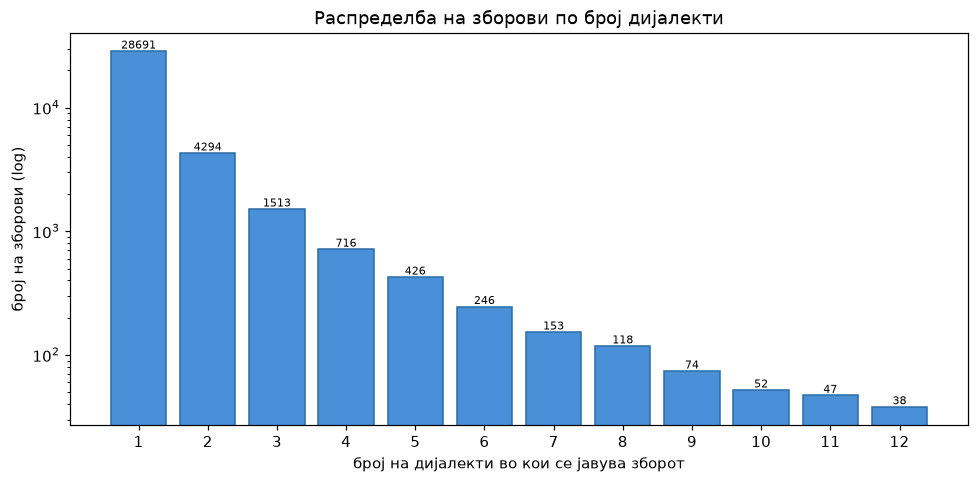

ексклузивни (1 дијалект): 28691   споделени (>=2): 7677


In [5]:
stats = json.loads((ROOT / 'output' / 'stats.json').read_text(encoding='utf-8'))
for k in ['total_triples', 'lexemes', 'total_word_occurrences', 'variant_pairs',
          'dialects_with_data']:
    print(f'{k:24}: {stats.get(k)}')

dist = Counter()
for lex in data.subjects(RDF.type, VEZ['Лексема']):
    dist[len(set(data.objects(lex, VEZ.appearsInDialect)))] += 1

xs = sorted(dist)
ys = [dist[x] for x in xs]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(xs, ys, color='#4a90d9', edgecolor='#2b6ca3')
ax.set_yscale('log')
ax.set_xlabel('број на дијалекти во кои се јавува зборот')
ax.set_ylabel('број на зборови (log)')
ax.set_title('Распределба на зборови по број дијалекти')
ax.set_xticks(xs)
for b, v in zip(bars, ys):
    ax.text(b.get_x() + b.get_width()/2, v, str(v), ha='center', va='bottom', fontsize=7)
plt.tight_layout(); plt.show()
print(f"ексклузивни (1 дијалект): {dist[1]}   споделени (>=2): {sum(v for k,v in dist.items() if k>=2)}")

## 4. Венов дијаграм — споделена лексика

Вистински пропорционален Венов дијаграм работи за **2–3 множества**. Тука земаме три
дијалекти и ги броиме ексклузивните и споделените зборови.

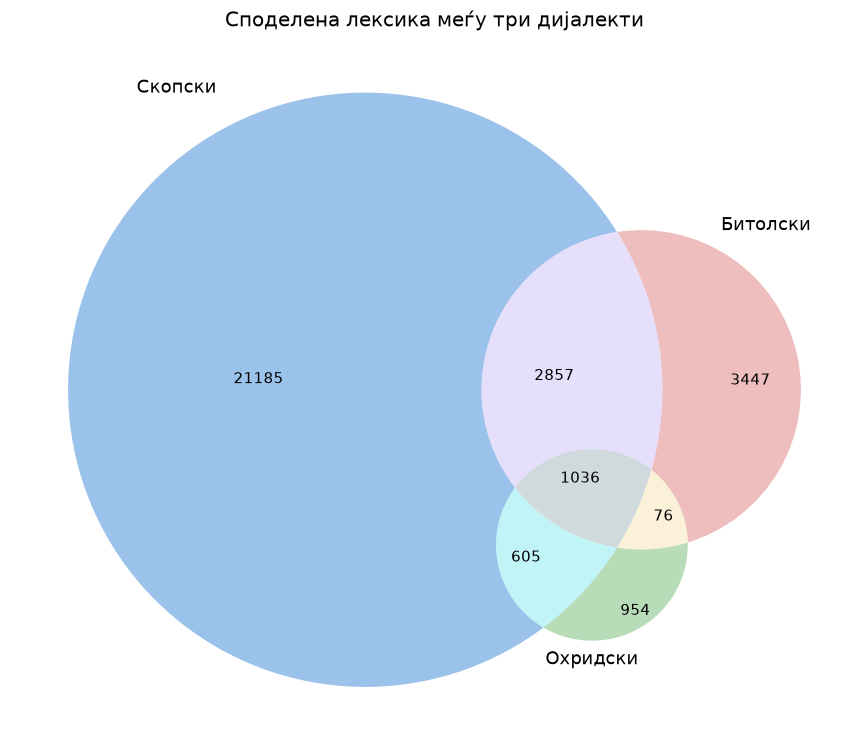

Скопски: 25683 | Битолски: 7416 | Охридски: 2671 зборови
заеднички за сите три: 1036


In [6]:
def words_of(dkey):
    duri = VEZR[dkey]
    return {str(data.value(l, VEZ.wordForm))
            for l in data.subjects(VEZ.appearsInDialect, duri)}

trio = ['skopski', 'bitolski', 'ohridski']
A, B, C = (words_of(d) for d in trio)
names = [pref(VEZR[d]) for d in trio]

fig, ax = plt.subplots(figsize=(8, 7))
v = venn3([A, B, C], set_labels=names, ax=ax,
          set_colors=('#4a90d9', '#e08a8a', '#7fbf7f'), alpha=0.55)
ax.set_title('Споделена лексика меѓу три дијалекти', fontsize=13)
plt.tight_layout(); plt.show()
print(f'{names[0]}: {len(A)} | {names[1]}: {len(B)} | {names[2]}: {len(C)} зборови')
print('заеднички за сите три:', len(A & B & C))

## 5. Мрежни прикази (force-directed)

Дијалектите се **јазли-центри**; зборовите се закачени на дијалектите во кои се јавуваат.
Force layout-от ексклузивните зборови ги држи до својот центар, а споделените ги повлекува
*меѓу* центрите — оттаму „Венов" впечаток.

In [7]:
DIALECT_COLORS = plt.cm.tab20.colors

def dialect_hubs():
    return [lname(d) for d in data.subjects(RDF.type, VEZ['Дијалект'])
            if lname(d) in {lname(x) for x in data.objects(None, VEZ.appearsInDialect)}]

hubs = sorted(dialect_hubs())
hub_color = {h: DIALECT_COLORS[i % len(DIALECT_COLORS)] for i, h in enumerate(hubs)}

def lex_dialects(lex):
    return sorted(lname(d) for d in data.objects(lex, VEZ.appearsInDialect))

def build_word_graph(predicate):
    """predicate(n_dialects, dialect_list) -> bool ; returns networkx graph"""
    G = nx.Graph()
    for h in hubs:
        G.add_node(('D', h), kind='hub')
    for lex in data.subjects(RDF.type, VEZ['Лексема']):
        ds = lex_dialects(lex)
        if not predicate(len(ds), ds):
            continue
        w = str(data.value(lex, VEZ.wordForm))
        wn = ('W', w)
        G.add_node(wn, kind='word')
        for d in ds:
            if ('D', d) in G:
                G.add_edge(wn, ('D', d))
    return G

def draw_word_graph(G, title):
    pos = nx.spring_layout(G, k=0.45, seed=7, iterations=120)
    hub_nodes = [n for n in G if n[0] == 'D']
    word_nodes = [n for n in G if n[0] == 'W']
    def wcol(n):
        nb = [d[1] for d in G.neighbors(n)]
        if len(nb) == 1:
            return hub_color[nb[0]]
        return '#9aa0a6'
    fig, ax = plt.subplots(figsize=(12, 9))
    nx.draw_networkx_edges(G, pos, alpha=0.18, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=word_nodes, node_size=28,
                           node_color=[wcol(n) for n in word_nodes], ax=ax, linewidths=0)
    nx.draw_networkx_nodes(G, pos, nodelist=hub_nodes, node_size=900,
                           node_color=[hub_color[n[1]] for n in hub_nodes],
                           edgecolors='black', ax=ax)
    nx.draw_networkx_labels(G, pos, labels={n: pref(VEZR[n[1]]) for n in hub_nodes},
                            font_size=9, font_weight='bold', ax=ax)
    ax.set_title(title, fontsize=13); ax.axis('off'); plt.tight_layout(); plt.show()

print('hubs:', len(hubs))

hubs: 12


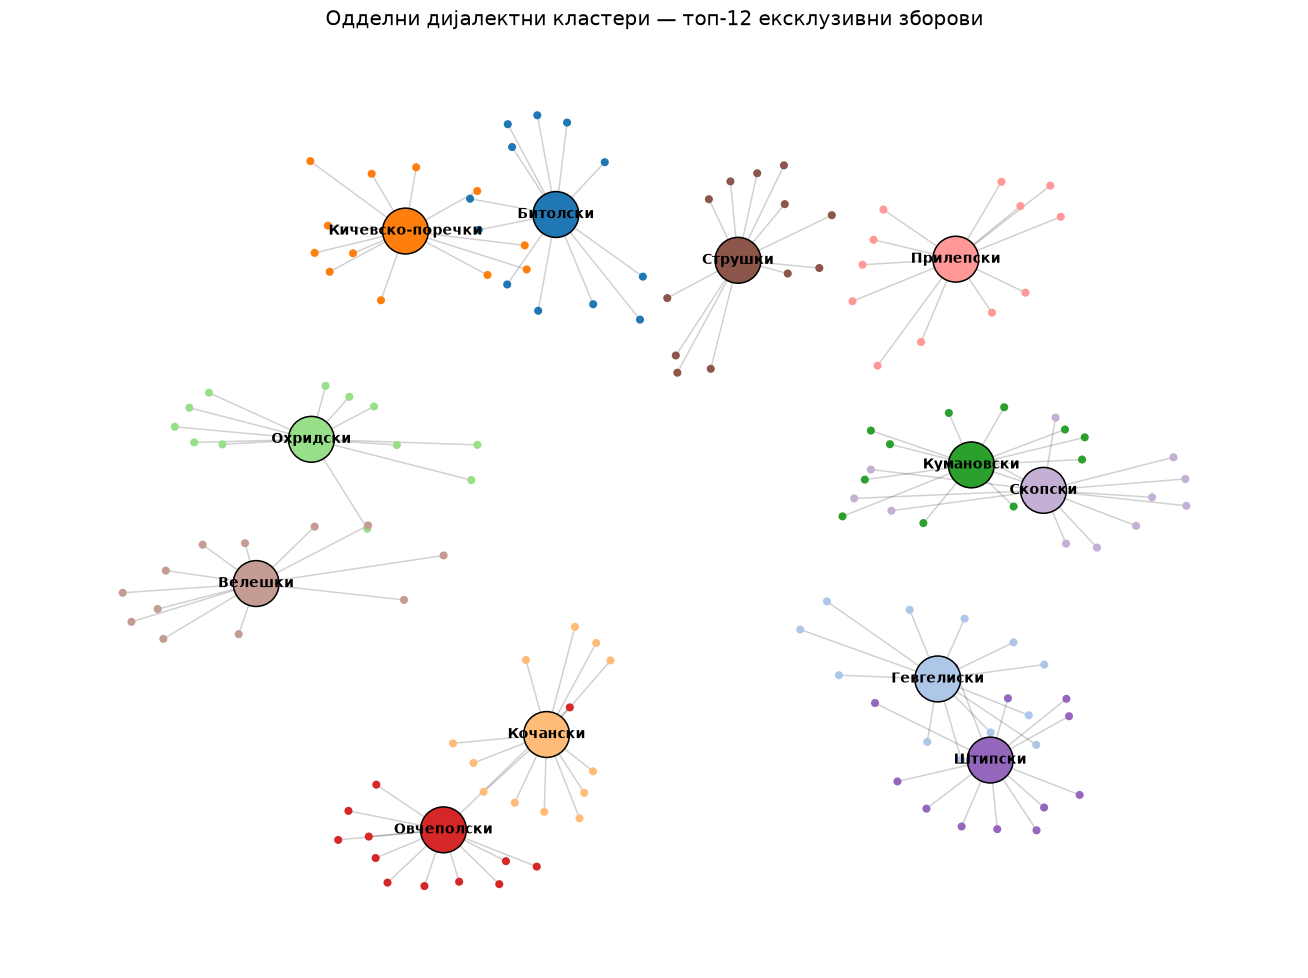

In [8]:
import heapq
G = nx.Graph()
for h in hubs:
    G.add_node(('D', h), kind='hub')
per = {h: [] for h in hubs}
for lex in data.subjects(RDF.type, VEZ['Лексема']):
    ds = lex_dialects(lex)
    if len(ds) != 1:
        continue
    d = ds[0]
    freq = int(data.value(lex, VEZ.frequency))
    per[d].append((freq, str(data.value(lex, VEZ.wordForm))))
for d, lst in per.items():
    for freq, w in heapq.nlargest(12, lst):
        G.add_node(('W', w + '·' + d), kind='word')
        G.add_edge(('W', w + '·' + d), ('D', d))
draw_word_graph(G, 'Одделни дијалектни кластери — топ-12 ексклузивни зборови')

## 6. Живо истражување во Neo4j Aura (Cypher)

Истиот граф е во **Neo4j Aura**. За интерактивно разгледување (zoom/pan, бои по дијалект),
отвори ја **Query** конзолата и залепи.

```cypher
// Споделено јадро — зборови во ≥9 дијалекти, повлечени меѓу сите 12 центри
MATCH (l:Lexeme)-[:APPEARS_IN_DIALECT]->(d:Dialect)
WITH l, count(*) AS dn WHERE dn >= 9
MATCH p=(l)-[:APPEARS_IN_DIALECT]->(:Dialect)
RETURN p;
```

```cypher
// 12 одделни лоби — топ-15 ексклузивни зборови по дијалект
MATCH (l:Lexeme)-[:APPEARS_IN_DIALECT]->(d:Dialect)
WITH l, count(*) AS dn WHERE dn = 1
MATCH (l)-[:APPEARS_IN_DIALECT]->(d:Dialect)
WITH d, l ORDER BY l.frequency DESC
WITH d, collect(l)[0..15] AS top
UNWIND top AS l
MATCH p=(l)-[:APPEARS_IN_DIALECT]->(d)
RETURN p;
```

```cypher
// Венов приказ на 2–3 дијалекти (~196 јазли)
WITH ['skopski','bitolski','ohridski'] AS sel
MATCH (l:Lexeme)
WITH sel, l, [(l)-[:APPEARS_IN_DIALECT]->(x) | x.uri] AS ds
WHERE size(ds) >= 1 AND all(z IN ds WHERE z IN sel) AND l.frequency >= 20
MATCH p=(l)-[:APPEARS_IN_DIALECT]->(:Dialect)
RETURN p;
```
